In [2]:
import pandas as pd
import ssl
import matplotlib.pyplot as plt

ssl._create_default_https_context = ssl._create_unverified_context

default_url = url = "https://www.football-data.co.uk/mmz4281/2324/E0.csv"
df = pd.read_csv(url)

print("DataFrame loaded successfully!")

print(df.shape)
print(df.info())
print(df.describe())
print (df.columns)
print(df.head())

DataFrame loaded successfully!
(380, 106)
<class 'pandas.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Columns: 106 entries, Div to AvgCAHA
dtypes: float64(82), int64(16), str(8)
memory usage: 314.8 KB
None
             FTHG        FTAG        HTHG        HTAG          HS          AS  \
count  380.000000  380.000000  380.000000  380.000000  380.000000  380.000000   
mean     1.800000    1.478947    0.734211    0.626316   15.402632   12.181579   
std      1.365616    1.277811    0.831687    0.823367    6.261959    5.467696   
min      0.000000    0.000000    0.000000    0.000000    1.000000    2.000000   
25%      1.000000    1.000000    0.000000    0.000000   11.000000    8.000000   
50%      2.000000    1.000000    1.000000    0.000000   15.000000   11.000000   
75%      3.000000    2.000000    1.000000    1.000000   19.000000   15.000000   
max      6.000000    8.000000    4.000000    5.000000   36.000000   30.000000   

              HST         AST          HF          AF  ...    A

In [3]:
temporadas = ["2021", "2122", "2223", "2324", "2425"]
base_url = "https://www.football-data.co.uk/mmz4281/{}/E0.csv"

dfs = []
for t in temporadas:
    df_temp = pd.read_csv(base_url.format(t))
    df_temp["season"] = t
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)
print(df.shape)   # ~1900 partidos, 5 temporadas

df.head()
print(df.shape)
print(df.columns.tolist())


(1900, 133)
(1900, 133)
['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'Referee', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D', 'B365A', 'BWH', 'BWD', 'BWA', 'IWH', 'IWD', 'IWA', 'PSH', 'PSD', 'PSA', 'WHH', 'WHD', 'WHA', 'VCH', 'VCD', 'VCA', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'B365>2.5', 'B365<2.5', 'P>2.5', 'P<2.5', 'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5', 'AHh', 'B365AHH', 'B365AHA', 'PAHH', 'PAHA', 'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'B365CH', 'B365CD', 'B365CA', 'BWCH', 'BWCD', 'BWCA', 'IWCH', 'IWCD', 'IWCA', 'PSCH', 'PSCD', 'PSCA', 'WHCH', 'WHCD', 'WHCA', 'VCCH', 'VCCD', 'VCCA', 'MaxCH', 'MaxCD', 'MaxCA', 'AvgCH', 'AvgCD', 'AvgCA', 'B365C>2.5', 'B365C<2.5', 'PC>2.5', 'PC<2.5', 'MaxC>2.5', 'MaxC<2.5', 'AvgC>2.5', 'AvgC<2.5', 'AHCh', 'B365CAHH', 'B365CAHA', 'PCAHH', 'PCAHA', 'MaxCAHH', 'MaxCAHA', 'AvgCAHH', 'AvgCAHA', 'season', 'BFH', 'BFD', 'BFA', '1XBH', '1XBD', '1XBA',

/var/folders/zh/d482rvp50vz28_swlkzgxkq80000gn/T/ipykernel_8619/3397216643.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_temp["season"] = t


In [4]:

nulos = df.isnull().sum()
print(nulos[nulos > 0])

print('Columnas utiles para el análisis: ')
cols_utiles = ['HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HS', 'AS', 'HST', 'AST', 'HC', 'AC']
print(df[cols_utiles].isnull().sum())


BWH          143
BWD          143
BWA          143
IWH          562
IWD          562
IWA          562
WHH           91
WHD           91
WHA           91
VCH          380
VCD          380
VCA          380
B365>2.5       1
B365<2.5       1
P>2.5         12
P<2.5         12
BWCH         153
BWCD         153
BWCA         153
IWCH         565
IWCD         565
IWCA         565
WHCH          91
WHCD          91
WHCA          91
VCCH         380
VCCD         380
VCCA         380
PC>2.5        11
PC<2.5        11
B365CAHH       1
B365CAHA       1
MaxCAHH        1
MaxCAHA        1
BFH         1521
BFD         1521
BFA         1521
1XBH        1529
1XBD        1529
1XBA        1529
BFEH        1520
BFED        1520
BFEA        1520
BFE>2.5     1523
BFE<2.5     1523
BFEAHH      1520
BFEAHA      1520
BFCH        1520
BFCD        1520
BFCA        1520
1XBCH       1520
1XBCD       1520
1XBCA       1520
BFECH       1520
BFECD       1520
BFECA       1520
BFEC>2.5    1520
BFEC<2.5    1520
BFECAHH     15

In [5]:
# HomeTeam  - Equipo local
# AwayTeam  - Equipo visitante
# FTHG      - Full Time Home Goals: goles del local al final
# FTAG      - Full Time Away Goals: goles del visitante al final
# FTR       - Full Time Result: H=local gana, A=visitante gana, D=empate
# HS        - Home Shots: tiros totales del local
# AS        - Away Shots: tiros totales del visitante
# HST       - Home Shots on Target: tiros a puerta del local
# AST       - Away Shots on Target: tiros a puerta del visitante
# HC        - Home Corners: córners del local
# AC        - Away Corners: córners del visitante
cols_utiles = ['HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HS', 'AS', 'HST', 'AST', 'HC', 'AC']
df_clean = df[cols_utiles].dropna()


print("Partidos después de limpiar:", len(df_clean))
print("\nDistribución de resultados:")
print(df_clean['FTR'].value_counts())
df_clean.to_csv("english_league.csv", index=False)

Partidos después de limpiar: 1900

Distribución de resultados:
FTR
H    821
A    646
D    433
Name: count, dtype: int64


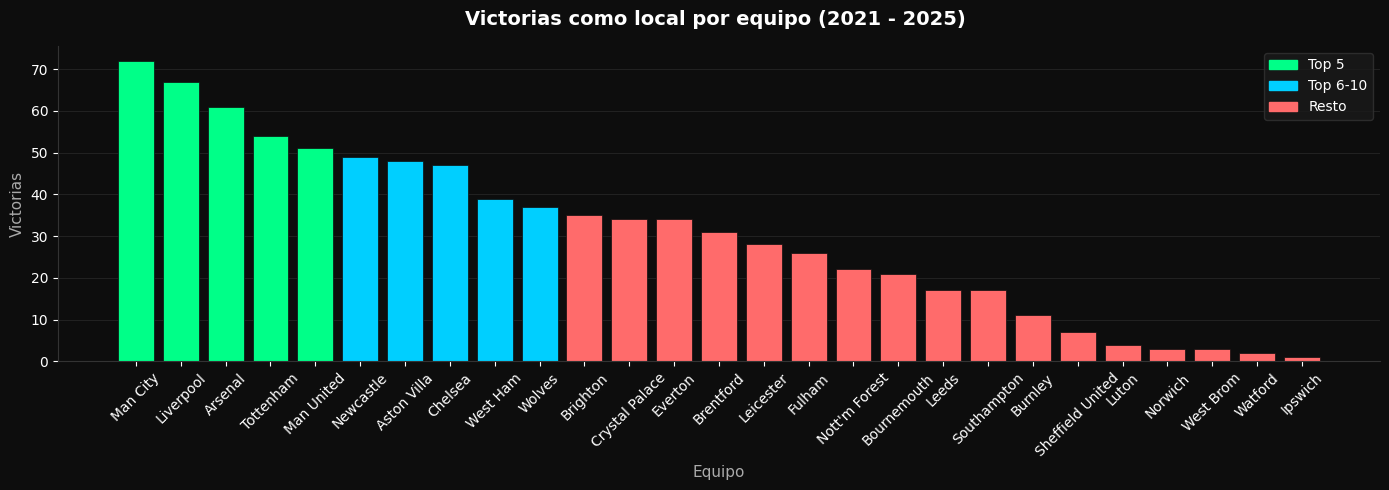

In [6]:
# Victorias por equipo como local
victorias_local = df_clean[df_clean['FTR'] == 'H'].groupby('HomeTeam').size().sort_values(ascending=False)

colors = ['#00ff88' if i < 5 else '#00cfff' if i < 10 else '#ff6b6b' for i in range(len(victorias_local))]

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#0d0d0d')

bars = ax.bar(victorias_local.index, victorias_local.values, color=colors, edgecolor='#0d0d0d', linewidth=0.5)

ax.set_title('Victorias como local por equipo (2021 - 2025) ', fontsize=14, fontweight='bold', color='white', pad=15)
ax.set_xlabel('Equipo', fontsize=11, color='#aaaaaa')
ax.set_ylabel('Victorias', fontsize=11, color='#aaaaaa')
ax.tick_params(axis='x', rotation=45, colors='white')
ax.tick_params(axis='y', colors='white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')
ax.yaxis.grid(True, color='#222222', linewidth=0.7)
ax.set_axisbelow(True)

from matplotlib.patches import Patch
legend = [Patch(color='#00ff88', label='Top 5'), Patch(color='#00cfff', label='Top 6-10'), Patch(color='#ff6b6b', label='Resto')]
ax.legend(handles=legend, loc='upper right', facecolor='#1a1a1a', edgecolor='#333333', labelcolor='white')

plt.tight_layout()
plt.show()

In [7]:
# Para cada equipo, calcular sus stats agregadas de la temporada
equipos = pd.concat([df_clean['HomeTeam'], df_clean['AwayTeam']]).unique()

stats = []

for equipo in equipos:
    # Partidos como local
    local = df_clean[df_clean['HomeTeam'] == equipo]
    
    # Partidos como visitante
    visita = df_clean[df_clean['AwayTeam'] == equipo]

    partidos = len(local) + len(visita)

    # Victorias
    vic_local = (local['FTR'] == 'H').sum()
    vic_visita = (visita['FTR'] == 'A').sum()
    victorias = vic_local + vic_visita

    # Goles a favor y en contra
    goles_favor = local['FTHG'].sum() + visita['FTAG'].sum()
    goles_contra = local['FTAG'].sum() + visita['FTHG'].sum()

    # Shots on target
    sot_favor = local['HST'].sum() + visita['AST'].sum()
    sot_contra = local['AST'].sum() + visita['HST'].sum()

    # Corners
    corners_favor = local['HC'].sum() + visita['AC'].sum()

    stats.append({
        'equipo': equipo,
        'partidos': partidos,
        'victorias': victorias,
        'win_rate': victorias / partidos,
        'goles_favor_pg': goles_favor / partidos,
        'goles_contra_pg': goles_contra / partidos,
        'diferencia_goles': (goles_favor - goles_contra) / partidos,
        'sot_favor_pg': sot_favor / partidos,
        'sot_contra_pg': sot_contra / partidos,
        'corners_pg': corners_favor / partidos,
        'vic_local': vic_local,
        'vic_visita': vic_visita,
    })

df_equipos = pd.DataFrame(stats)
print(df_equipos.sort_values('win_rate', ascending=False).head(30))

              equipo  partidos  victorias  win_rate  goles_favor_pg  \
19          Man City       190        133  0.700000        2.336842   
2          Liverpool       190        116  0.610526        2.152632   
11           Arsenal       190        114  0.600000        1.915789   
5          Tottenham       190         89  0.468421        1.815789   
10        Man United       190         89  0.468421        1.521053   
14           Chelsea       190         89  0.468421        1.647368   
16       Aston Villa       190         86  0.452632        1.536842   
13         Newcastle       190         82  0.431579        1.636842   
3           West Ham       190         71  0.373684        1.421053   
20         Brentford       152         54  0.355263        1.500000   
6           Brighton       190         67  0.352632        1.447368   
23       Bournemouth       114         39  0.342105        1.307018   
17            Wolves       190         63  0.331579        1.100000   
24    

In [8]:
from sklearn.model_selection import train_test_split

# Features (X) y target (y)
features = [
    'goles_favor_pg',
    'goles_contra_pg',
    'diferencia_goles',
    'sot_favor_pg',
    'sot_contra_pg',
    'corners_pg',
    'vic_local',
    'vic_visita'
]

X = df_equipos[features]
y = df_equipos['win_rate']

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test: ", X_test.shape)

Train: (21, 8)
Test:  (6, 8)


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenar
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Modelo entrenado")
print("\nCoeficientes por feature:")
for feature, coef in zip(features, model.coef_):
    print(f"  {feature:<25} {coef:.4f}")

print(f"\nIntercepto: {model.intercept_:.4f}")

Modelo entrenado

Coeficientes por feature:
  goles_favor_pg            0.0230
  goles_contra_pg           -0.0215
  diferencia_goles          0.0232
  sot_favor_pg              0.0134
  sot_contra_pg             0.0123
  corners_pg                0.0010
  vic_local                 0.0656
  vic_visita                0.0252

Intercepto: 0.3299


# Describing next steps

Estas tres líneas hacen el feature scaling que vimos en la teoría. Te las desgloso una por una:

- scaler = StandardScaler() — crea el objeto scaler. Todavía no hace nada con los datos, solo inicializa la herramienta.
- scaler.fit_transform(X_train) — hace dos cosas en una sola llamada:

fit — calcula la media (μ) y desviación estándar (σ) de cada feature usando solo X_train
transform — aplica la fórmula z = (x - μ) / σ a cada valor

El resultado es que cada feature queda con media 0 y std 1. Por ejemplo, goles_favor_pg que tenía valores entre 0.6 y 2.3 ahora tiene valores entre -2 y +2 aproximadamente.

scaler.transform(X_test) — aplica el mismo μ y σ que calculó en X_train sobre los datos de test. Nótese que es solo transform, no fit_transform.
Aquí está el punto clave que ya internalizaste del proyecto de fútbol anterior: nunca hacer fit sobre X_test. Si calcularas nuevas estadísticas con los datos de test estarías introduciendo información del futuro en el modelo — data leakage. El test set debe escalarse con los parámetros del training set, exactamente igual que cuando predices datos nuevos en producción.

μ (media) — el promedio de cada feature calculado sobre X_train. Puedes verlos así:
pythonprint(scaler.mean_)

σ (desviación estándar) — qué tan dispersos están los valores de cada feature. Puedes verlos así:
pythonprint(scaler.scale_)

Y la fórmula del scaler junta ambos en una sola operación:
z = (x - μ) / σ

Restar μ centra los datos en 0 — todos los equipos se miden como distancia al promedio de la liga
Dividir por σ normaliza la escala — un equipo que se desvía mucho en goles se compara justo con uno que se desvía mucho en corners

El resultado z te dice algo intuitivo: cuántas desviaciones estándar está ese equipo sobre o bajo el promedio de la liga.
z =  0   →  equipo promedio
z =  2   →  muy por encima del promedio
z = -2   →  muy por debajo del promedio


vic_local (0.0656) y vic_visita (0.0252) son los más altos por lejos, lo cual tiene sentido matemático pero es un problema de data leakage — estás usando victorias para predecir win rate, que es básicamente victorias dividido partidos. El modelo está haciendo trampa.
Saquemos esos dos features y reentrenemos con features que sean realmente predictivos e independientes:

In [ ]:
# Features limpios — sin vic_local ni vic_visita
features_clean = [
    'goles_favor_pg',
    'goles_contra_pg',
    'diferencia_goles',
    'sot_favor_pg',
    'sot_contra_pg',
    'corners_pg'
]

X = df_equipos[features_clean]
y = df_equipos['win_rate']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling y entrenamiento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("\n Coeficientes por feature - sin orden:")
for feature, coef in zip(features_clean, model.coef_):
    print(f"  {feature:<25} {coef:.4f}")




## Coeficientes ordenados por importancia (valor absoluto)
print("\n Coeficientes por feature (orden de importancia):")
coef_df = pd.DataFrame({
    'feature': features_clean,
    'coeficiente': model.coef_
})

coef_df['importancia'] = coef_df['coeficiente'].abs()
coef_df = coef_df.sort_values('importancia', ascending=False)

for _, row in coef_df.iterrows():
    signo = "+" if row['coeficiente'] > 0 else ""
    print(f"  {row['feature']:<25} {signo}{row['coeficiente']:.4f}")


print(f"\nIntercepto: {model.intercept_:.4f}")



 Coeficientes por feature - sin orden:
  goles_favor_pg            0.0302
  goles_contra_pg           -0.0542
  diferencia_goles          0.0434
  sot_favor_pg              0.0249
  sot_contra_pg             -0.0019
  corners_pg                0.0061

 Coeficientes por feature (orden de importancia):
  goles_contra_pg           -0.0542
  diferencia_goles          +0.0434
  goles_favor_pg            +0.0302
  sot_favor_pg              +0.0249
  corners_pg                +0.0061
  sot_contra_pg             -0.0019

Intercepto: 0.3299


In [27]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Predicciones
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

# Métricas
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print("=== TRAIN ===")
print(f"  R²:   {r2_train:.4f}")
print(f"  RMSE: {rmse_train:.4f}")


print("\n=== TEST ===")
print(f"  R² (varianza explicada por el modelo):   {r2_test:.4f}")
print(f"  RMSE (error promedio del modelo): {rmse_test:.4f}")


# Predicciones vs reales
resultados = pd.DataFrame({
    'equipo': df_equipos.loc[X_test.index, 'equipo'].values,
    'win_rate_real': y_test.values,
    'win_rate_pred': y_pred_test.round(3)
})
print("\n=== Predicciones vs Reales ===")
print(resultados.sort_values('win_rate_real', ascending=False).to_string(index=False))

=== TRAIN ===
  R²:   0.9574
  RMSE: 0.0327

=== TEST ===
  R² (varianza explicada por el modelo):   0.9686
  RMSE (error promedio del modelo): 0.0241

=== Predicciones vs Reales ===
   equipo  win_rate_real  win_rate_pred
  Arsenal       0.600000          0.555
Newcastle       0.431579          0.421
  Everton       0.315789          0.326
   Fulham       0.315789          0.348
    Leeds       0.298246          0.284
  Watford       0.157895          0.159


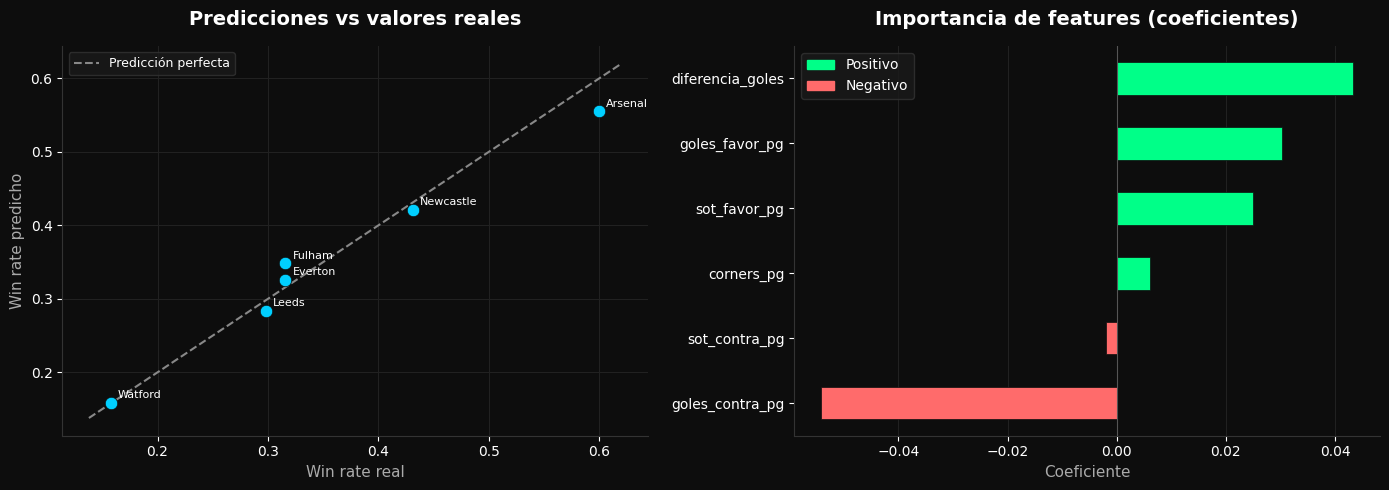

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d0d0d')

# --- Gráfico 1: Predicciones vs Reales ---
ax1 = axes[0]
ax1.set_facecolor('#0d0d0d')

ax1.scatter(y_test, y_pred_test, color='#00cfff', s=80, zorder=3, edgecolors='#0d0d0d', linewidths=0.5)

# Línea ideal
lims = [min(y_test.min(), y_pred_test.min()) - 0.02,
        max(y_test.max(), y_pred_test.max()) + 0.02]
ax1.plot(lims, lims, '--', color='#888', linewidth=1.5, label='Predicción perfecta')

# Etiquetas por punto
equipos_test = df_equipos.loc[X_test.index, 'equipo'].values
for i, eq in enumerate(equipos_test):
    ax1.annotate(eq, (y_test.values[i], y_pred_test[i]),
                 fontsize=8, xytext=(5, 3), textcoords='offset points', color='white')

ax1.set_xlabel('Win rate real', fontsize=11, color='#aaaaaa')
ax1.set_ylabel('Win rate predicho', fontsize=11, color='#aaaaaa')
ax1.set_title('Predicciones vs valores reales', fontsize=14, fontweight='bold', color='white', pad=15)
ax1.tick_params(axis='x', colors='white')
ax1.tick_params(axis='y', colors='white')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#333333')
ax1.spines['bottom'].set_color('#333333')
ax1.yaxis.grid(True, color='#222222', linewidth=0.7)
ax1.xaxis.grid(True, color='#222222', linewidth=0.7)
ax1.set_axisbelow(True)
ax1.legend(fontsize=9, facecolor='#1a1a1a', edgecolor='#333333', labelcolor='white')

# --- Gráfico 2: Importancia de features ---
ax2 = axes[1]
ax2.set_facecolor('#0d0d0d')

coefs = pd.Series(model.coef_, index=features_clean).sort_values()
colors = ['#ff6b6b' if c < 0 else '#00ff88' for c in coefs]
coefs.plot(kind='barh', ax=ax2, color=colors, edgecolor='#0d0d0d', linewidth=0.5)

ax2.axvline(0, color='#555555', linewidth=0.8)
ax2.set_title('Importancia de features (coeficientes)', fontsize=14, fontweight='bold', color='white', pad=15)
ax2.set_xlabel('Coeficiente', fontsize=11, color='#aaaaaa')
ax2.tick_params(axis='x', colors='white')
ax2.tick_params(axis='y', colors='white')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#333333')
ax2.spines['bottom'].set_color('#333333')
ax2.xaxis.grid(True, color='#222222', linewidth=0.7)
ax2.set_axisbelow(True)

legend2 = [Patch(color='#00ff88', label='Positivo'), Patch(color='#ff6b6b', label='Negativo')]
ax2.legend(handles=legend2, facecolor='#1a1a1a', edgecolor='#333333', labelcolor='white')

plt.tight_layout()
plt.show()

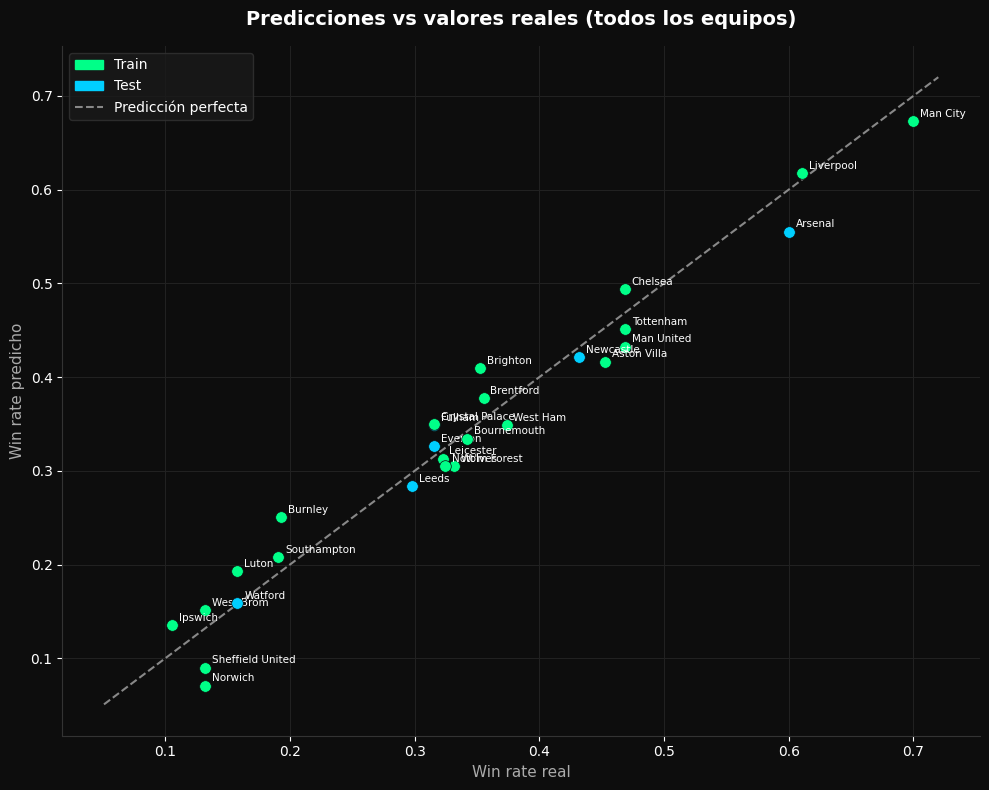

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Predecir sobre todos los equipos
X_all_scaled = scaler.transform(df_equipos[features_clean])
y_pred_all = model.predict(X_all_scaled)
y_real_all = df_equipos['win_rate'].values
equipos_all = df_equipos['equipo'].values

# Identificar cuáles son test
test_idx = set(X_test.index)
is_test = [i in test_idx for i in df_equipos.index]

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#0d0d0d')

for i, eq in enumerate(equipos_all):
    color = '#00cfff' if is_test[i] else '#00ff88'
    ax.scatter(y_real_all[i], y_pred_all[i], color=color, s=70, zorder=3,
               edgecolors='#0d0d0d', linewidths=0.5)
    ax.annotate(eq, (y_real_all[i], y_pred_all[i]),
                fontsize=7.5, xytext=(5, 3), textcoords='offset points', color='white')

# Línea ideal
lims = [min(y_real_all.min(), y_pred_all.min()) - 0.02,
        max(y_real_all.max(), y_pred_all.max()) + 0.02]
ax.plot(lims, lims, '--', color='#888', linewidth=1.5)

ax.set_xlabel('Win rate real', fontsize=11, color='#aaaaaa')
ax.set_ylabel('Win rate predicho', fontsize=11, color='#aaaaaa')
ax.set_title('Predicciones vs valores reales (todos los equipos)', fontsize=14, fontweight='bold', color='white', pad=15)
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')
ax.yaxis.grid(True, color='#222222', linewidth=0.7)
ax.xaxis.grid(True, color='#222222', linewidth=0.7)
ax.set_axisbelow(True)

legend = [
    Patch(color='#00ff88', label='Train'),
    Patch(color='#00cfff', label='Test'),
    plt.Line2D([0], [0], linestyle='--', color='#888', label='Predicción perfecta'),
]
ax.legend(handles=legend, facecolor='#1a1a1a', edgecolor='#333333', labelcolor='white')

plt.tight_layout()
plt.show()


In [19]:
def predecir_equipo(goles_favor, goles_contra, sot_favor, sot_contra, corners):
    """
    Predice el win rate de un equipo hipotético.
    
    Parámetros (todos por partido):
    - goles_favor:  goles anotados promedio
    - goles_contra: goles recibidos promedio
    - sot_favor:    shots on target a favor
    - sot_contra:   shots on target en contra
    - corners:      corners a favor
    """
    diferencia = goles_favor - goles_contra
    
    nuevo_equipo = pd.DataFrame([{
        'goles_favor_pg':    goles_favor,
        'goles_contra_pg':   goles_contra,
        'diferencia_goles':  diferencia,
        'sot_favor_pg':      sot_favor,
        'sot_contra_pg':     sot_contra,
        'corners_pg':        corners
    }])
    
    nuevo_scaled = scaler.transform(nuevo_equipo)
    win_rate = model.predict(nuevo_scaled)[0]
    win_rate = max(0, min(1, win_rate))  # clamp entre 0 y 1
    
    # Buscar equipo más parecido en el dataset
    df_equipos['distancia'] = (
        (df_equipos['goles_favor_pg'] - goles_favor)**2 +
        (df_equipos['goles_contra_pg'] - goles_contra)**2 +
        (df_equipos['sot_favor_pg'] - sot_favor)**2
    ).apply(np.sqrt)
    parecido = df_equipos.nsmallest(1, 'distancia').iloc[0]
    
    print(f"Win rate predicho:     {win_rate:.1%}")
    print(f"Victorias estimadas:   {round(win_rate * 38)} de 38 partidos")
    print(f"Equipo más parecido:   {parecido['equipo']} ({parecido['win_rate']:.1%} win rate real)")
    
    # Clasificación aproximada
    if win_rate >= 0.60:
        nivel = "Candidato al título"
    elif win_rate >= 0.45:
        nivel = "Top 4 / Champions League"
    elif win_rate >= 0.35:
        nivel = "Mid table"
    elif win_rate >= 0.25:
        nivel = "Zona de descenso"
    else:
        nivel = "Candidato a descender"
    
    print(f"Clasificación:         {nivel}")

# --- Probá con distintos perfiles ---

print("=== Equipo ofensivo (estilo Man City) ===")
predecir_equipo(goles_favor=2.3, goles_contra=0.9, sot_favor=6.2, sot_contra=2.8, corners=7.0)

print("\n=== Equipo defensivo (bajo bloque) ===")
predecir_equipo(goles_favor=1.1, goles_contra=0.9, sot_favor=3.5, sot_contra=3.2, corners=4.0)

print("\n=== Equipo promedio de la liga ===")
predecir_equipo(goles_favor=1.4, goles_contra=1.4, sot_favor=4.5, sot_contra=4.5, corners=5.0)

print("\n=== Tu equipo hipotético ===")
predecir_equipo(goles_favor=1.8, goles_contra=1.2, sot_favor=5.0, sot_contra=3.8, corners=5.5)

=== Equipo ofensivo (estilo Man City) ===
Win rate predicho:     66.5%
Victorias estimadas:   25 de 38 partidos
Equipo más parecido:   Man City (70.0% win rate real)
Clasificación:         Candidato al título

=== Equipo defensivo (bajo bloque) ===
Win rate predicho:     41.7%
Victorias estimadas:   16 de 38 partidos
Equipo más parecido:   Everton (31.6% win rate real)
Clasificación:         Mid table

=== Equipo promedio de la liga ===
Win rate predicho:     38.6%
Victorias estimadas:   15 de 38 partidos
Equipo más parecido:   Aston Villa (45.3% win rate real)
Clasificación:         Mid table

=== Tu equipo hipotético ===
Win rate predicho:     49.6%
Victorias estimadas:   19 de 38 partidos
Equipo más parecido:   Arsenal (60.0% win rate real)
Clasificación:         Top 4 / Champions League
